<div style = "border: 1px solid black">
<b><center><font size = "5"> Projecto Prático 2 </font><center></b>

<b><center><font size = "3"> Redes Neuronais Convolucionais (CNN)
</font><center></b>
</div>



---



`Nome:` Leonor Rebola <br>
`Número:` 53663 <br>
`Curso:` Inteligência Artificial e Ciência de Dados <br>
`Email:` leonor.rebola@ubi.pt <br>
`UC:` Aprendizagem Computacional <br>


---



`Objetivo:` Treinar e comparar redes neuronais para reconhecer sinais de trânsito a partir de imagens do conjunto de dados fornecido.


---



# **Leitura do ficheiro**

---



In [ ]:
from google.colab import files
import zipfile
import os

# Ler o ficheiro
uploaded = files.upload()

# Para descompactar a pasta
zip_path = '/content/GTSRB.zip'
extract_path = '/content/'

os.makedirs(extract_path, exist_ok = True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

train_dir = os.path.join(extract_path, 'Training')
test_dir = os.path.join(extract_path, 'Test')

print("Train dir:", train_dir)
print("Test dir:", test_dir)

Saving GTSRB.zip to GTSRB.zip
Train dir: /content/Training
Test dir: /content/Test


O código seguinte cria automaticamente dois conjuntos separados, um deles para o treino e outro para a validação a partir das pastas originais do dataset.  Tem como intuito **baralhar as pastas das classes**, fazendo uma divisão de **80% para o treino** e **20% para a validação**, e copia cada classe por inteiro para o local correspondente.

Este código garante que <u>nenhuma imagem é misturada entre treino e validação</u>, mantendo uma separação limpa e coerente por classes.

In [ ]:
import os
import shutil
import random

random.seed(42)

source_dir = train_dir
base_split = "/content/dataset_split_correct"
train_split = os.path.join(base_split, "train")
val_split = os.path.join(base_split, "val")

# Apagar se já existir
if os.path.exists(base_split):
    shutil.rmtree(base_split)

os.makedirs(train_split, exist_ok=True)
os.makedirs(val_split, exist_ok=True)

# Para cada classe, fazer split imagem a imagem
for class_name in sorted(os.listdir(source_dir)):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split_idx = int(0.8 * len(images))
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    # criar pastas da classe em train e val
    os.makedirs(os.path.join(train_split, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_split, class_name), exist_ok=True)

    # copiar imagens
    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(train_split, class_name, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(val_split, class_name, img)
        )

print("Split concluído.")

Split concluído.


# **Pré-processamento das imagens**

---



**`Treino e validação`**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Caminho da pasta de treino
train_dir = '/content/Training'  # Caminho real do treino

# Dimensões das imagens (filtro e característica)
img_height, img_width = 64, 64
batch_size = 32
# Definição do número de classes
num_classes = 43

# Conjunto de treino
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=False,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Divisão do treino (validação separada)
val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"Treino: {train_generator.samples} imagens")
print(f"Validação: {val_generator.samples} imagens")

Found 21312 images belonging to 43 classes.
Found 5328 images belonging to 43 classes.
Treino: 21312 imagens
Validação: 5328 imagens


**`Teste`**

In [ ]:
import os
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

# Caminho da pasta de teste
test_dir = '/content/Test/Images'
csv_path = '/content/Test/Images/GT-final_test.csv'

# Lê o ficheiro CSV
test_labels = pd.read_csv(csv_path, sep=';')

# Carrega e processa as imagens
X_test = []
y_test = []

for _, row in test_labels.iterrows():
    img_path = os.path.join(test_dir, row['Filename'])
    img = load_img(img_path, target_size=(img_height, img_width))
    img = img_to_array(img) / 255.0
    X_test.append(img)
    y_test.append(row['ClassId'])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Total de imagens de teste: {X_test.shape[0]}")
print(f"Dimensão de cada imagem: {X_test.shape[1:]}")
print(f"Número de classes no teste: {len(np.unique(y_test))}")

Total de imagens de teste: 12630
Dimensão de cada imagem: (64, 64, 3)
Número de classes no teste: 43


Para treinar o modelo, foi utilizado o **ImageDataGenerator**, responsável por carregar as imagens da pasta Training e aplicar técnicas de data augmentation, como rotações, zoom e deslocamentos. Estas transformações aumentam artificialmente a variedade do conjunto de treino, ajudando o modelo a generalizar melhor. As imagens são também normalizadas e o próprio gerador cria automaticamente uma divisão entre treino (80%) e validação (20%).

No conjunto de teste, as imagens são carregadas manualmente com base na informação do ficheiro GT-final_test.csv, que indica o nome de cada imagem e a respetiva classe. Cada imagem é redimensionada para o mesmo tamanho usado no treino e normalizada da mesma forma. No final, obtém-se um conjunto de matrizes - `X_test` - e um vetor com os rótulos correspondentes - `y_test`, prontos para serem avaliados pelo modelo.

# **CNN**

---



O seguinte código mostra uma CNN implementada de forma manual, com **3 camadas convolucionais**  para classificar as imagens. Cada uma delas tem uma camada Conv2D, responsável por extrair padrões visuais, seguida de MaxPooling2D, que reduz a dimensionalidade e ajuda a reter as características mais relevantes.

Depois das três etapas de extração de características, o classificador transforma os resultados num vetor (Flatten), tendo também um pequeno classificador totalmente ligado (Dense) que transforma as características em previsões. Foi incluída uma camada Dropout para ajudar a reduzir o overfitting, desligando aleatoriamente algumas ativações durante o treino.

O modelo tem como função de custo a categorical crossentropy e utiliza EarlyStopping para evitar que treine por demasiado tempo e overfitting, recuperando automaticamente os melhores pesos.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 901,739 (3.44 MB)

 Trainable params: 901,739 (3.44 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.1277 - loss: 3.2513 - val_accuracy: 0.3086 - val_loss: 2.2997
Epoch 2/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.3661 - loss: 2.0481 - val_accuracy: 0.4904 - val_loss: 1.6898
Epoch 3/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.4878 - loss: 1.5548 - val_accuracy: 0.5567 - val_loss: 1.4629
Epoch 4/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.5933 - loss: 1.2078 - val_accuracy: 0.6586 - val_loss: 1.2078
Epoch 5/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.6944 - loss: 0.9072 - val_accuracy: 0.6580 - val_loss: 1.1497
Epoch 6/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.7587 - loss: 0.7174 - val_accuracy: 0.7517 - val_loss: 0.9744
Epoch 7/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.8162 - loss: 0.5616 - val_accuracy: 0.7742 - val_loss: 0.9306
Epoch 8/70
666/666 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.8406 - loss: 0.4704 - 

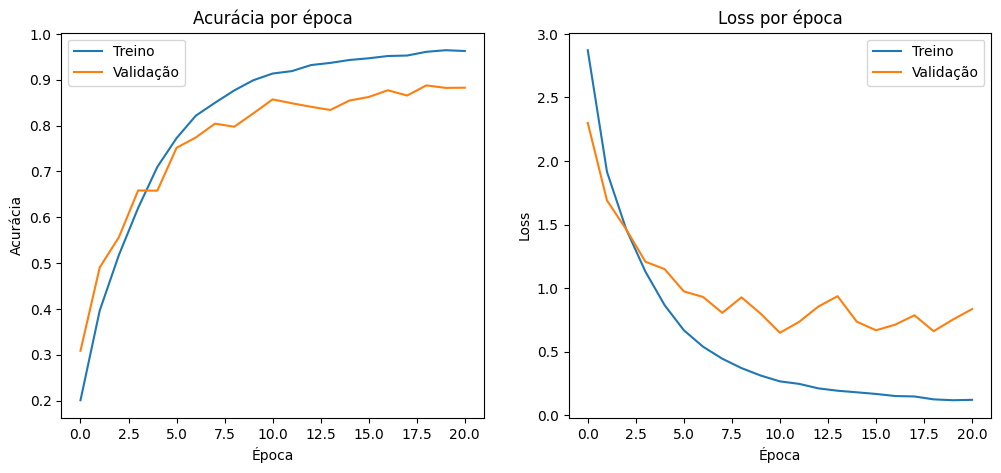

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Modelo
model = Sequential()
# Bloco 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3))) # extrai padrões locais das imagens.
model.add(MaxPooling2D((2,2))) # reduz a dimensão mantendo as características mais importantes.
# Bloco 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same')) # padding = same preenche a borda das imagens com 0's.
model.add(MaxPooling2D((2,2)))
# Bloco 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
# Classificador
model.add(Flatten()) # transforma os mapas de características num vetor.
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4)) # aplica dropout na camada anterior; para manter as curvas de learn e valid; aplica-se ao treino e não à validação.
model.add(Dense(num_classes, activation='softmax')) # converte a saída em probabilidades para as 43 classes.

# Treino do modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Sumário para verificar a nova estrutura
model.summary()

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
history = model.fit(train_generator, epochs=70, validation_data=val_generator, callbacks=[early_stop])

loss, acc = model.evaluate(X_test, to_categorical(y_test, num_classes))
print(f"Loss: {loss:.4f} - Accuracy: {acc:.4f}")

# Gráfico das curvas
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

Durante o treino, observou-se uma evolução consistente tanto na accuracy como no loss, indicando que o modelo foi aprendendo de forma progressiva ao longo das épocas. O mecanismo de EarlyStopping interrompeu o treino automaticamente na época 24, evitando que o modelo continuasse após indicar sinais de overfitting.

A accuracy da validação subiu de forma gradual nas primeiras épocas, estabilizando por volta dos 85%, enquanto que o loss diminuiu substancialmente antes de começar a oscilar.
\
No conjunto de teste, o modelo obteve **90.62% de accuracy** e **34.84% de loss**, demonstrando uma boa capacidade de generalização e confirmando que a arquitetura escolhida captou eficazmente as características essenciais das imagens de sinais de trânsito.

No geral, o modelo comportou-se de forma estável, sem divergências abruptas entre o treino e a validação.

# **Fine-tuning com MobileNetV2**

---



**`Pré-processamento das imagens`**

Tal como no exercício 1, o pré-processamento foi feito através do ImageDataGenerator, mas com diferenças importantes devido ao uso de um modelo pré-treinado. As imagens são redimensionadas para 128×128 (maiores que no exercício 1, que usou 32×32), pois este tipo de redes exigem resoluções mais elevadas para aproveitar totalmente as suas camadas convolucionais já treinadas no ImageNet.

O gerador aplica normalização e várias formas de data augmentation também, como rotações, zoom, deslocamentos e shear, ajudando a aumentar a robustez do modelo e a reduzir overfitting. Tal como no exercício anterior, o conjunto de treino é automaticamente dividido em 80% para treino e 20% para validação através do parâmetro validation_split.

Para o conjunto de teste, o processo é manual: cada imagem é carregada, redimensionada para 128×128 e normalizada, garantindo que os dados estão no mesmo formato que os do treino, tal como já acontecia no exercício 1. No entanto, aqui existe também a leitura de um ficheiro CSV que contém a classe correta de cada imagem, característica específica deste dataset.

**Treino**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Caminhos
train_dir = '/content/Training'
test_dir = '/content/Test/Images'
csv_path = '/content/Test/Images/GT-final_test.csv'

# Parâmetros
img_height, img_width = 128, 128
batch_size = 32
num_classes = 43

# Conjunto de treino
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,
    validation_split=0.2
)

# Geradores de treino e validação
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Divisão do treino (validação separada)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# Dicionário de classes
class_indices = train_generator.class_indices
print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("Class indices:", train_generator.class_indices)

Found 21312 images belonging to 43 classes.
Found 5328 images belonging to 43 classes.
Train samples: 21312
Val samples: 5328
Class indices: {'00000': 0, '00001': 1, '00002': 2, '00003': 3, '00004': 4, '00005': 5, '00006': 6, '00007': 7, '00008': 8, '00009': 9, '00010': 10, '00011': 11, '00012': 12, '00013': 13, '00014': 14, '00015': 15, '00016': 16, '00017': 17, '00018': 18, '00019': 19, '00020': 20, '00021': 21, '00022': 22, '00023': 23, '00024': 24, '00025': 25, '00026': 26, '00027': 27, '00028': 28, '00029': 29, '00030': 30, '00031': 31, '00032': 32, '00033': 33, '00034': 34, '00035': 35, '00036': 36, '00037': 37, '00038': 38, '00039': 39, '00040': 40, '00041': 41, '00042': 42}


**Teste**

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
import numpy as np
import pandas as pd

test_labels = pd.read_csv(csv_path, sep=';')
X_test, y_test = [], []

for _, row in test_labels.iterrows():
    img_path = os.path.join(test_dir, row['Filename'])
    img = load_img(img_path, target_size=(img_height, img_width))
    img = img_to_array(img) / 255.0
    X_test.append(img)
    y_test.append(row['ClassId'])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Imagens de teste: {X_test.shape[0]}")
print("Dimensão cada imagem:", X_test.shape[1:])
print("Classes no teste:", len(np.unique(y_test)))

Imagens de teste: 12630
Dimensão cada imagem: (128, 128, 3)
Classes no teste: 43


**`Rede MobileNetV2`**

Neste exercício, utilizou-se a MobileNetV2, uma rede pré-treinada no ImageNet, aplicando a técnica de transfer learning.

Primeiro, a base da MobileNetV2 foi carregada sem o topo (include_top=False) e mantida congelada, permitindo treinar apenas um “cabeçalho” personalizado composto por GlobalAveragePooling2D, uma camada Dense de 256 neurónios e Dropout de 40%. Esta fase ajusta apenas as novas camadas ao problema específico dos sinais de trânsito.

Numa segunda etapa realizou-se fine-tuning, descongelando as últimas 30 camadas da MobileNetV2. Assim, partes mais profundas da rede puderam adaptar-se aos dados, mas com um learning rate mais baixo para evitar destruir os pesos pré-treinados.

O treino foi controlado com EarlyStopping e ReduceLROnPlateau, que serve para reduzir a taxa de aprendizagem quando a validação estabiliza.

`Primeiro treino executado`

Com 60 camadas congeladas e 100 épocas na segunda fase.

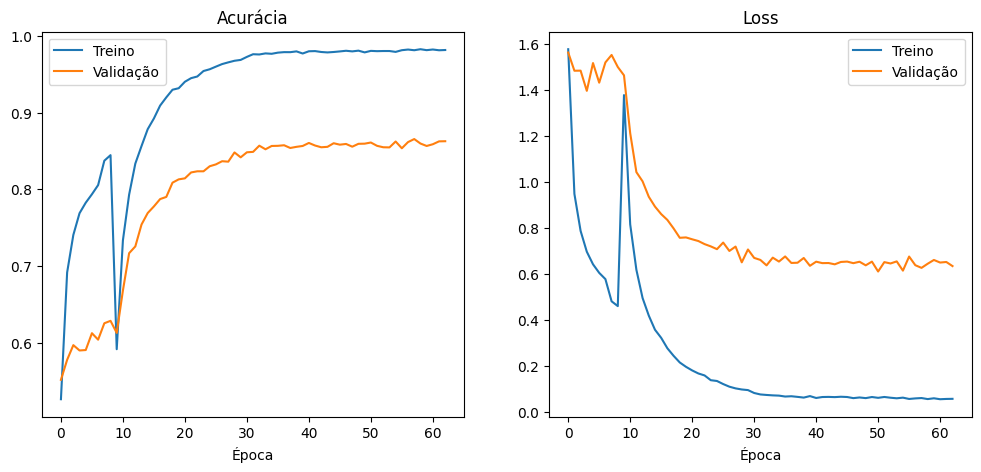

Epoch 1/40
666/666 ━━━━━━━━━━━━━━━━━━━━ 149s 209ms/step - accuracy: 0.4192 - loss: 2.1019 - val_accuracy: 0.5411 - val_loss: 1.5384 - learning_rate: 0.0010
Epoch 2/40
666/666 ━━━━━━━━━━━━━━━━━━━━ 130s 196ms/step - accuracy: 0.6660 - loss: 1.0224 - val_accuracy: 0.5845 - val_loss: 1.4903 - learning_rate: 0.0010
Epoch 3/40
666/666 ━━━━━━━━━━━━━━━━━━━━ 130s 195ms/step - accuracy: 0.7318 - loss: 0.8106 - val_accuracy: 0.6015 - val_loss: 1.4392 - learning_rate: 0.0010
Epoch 4/40
666/666 ━━━━━━━━━━━━━━━━━━━━ 130s 196ms/step - accuracy: 0.7551 - loss: 0.7252 - val_accuracy: 0.6006 - val_loss: 1.4242 - learning_rate: 0.0010
Epoch 5/40
666/666 ━━━━━━━━━━━━━━━━━━━━ 132s 198ms/step - accuracy: 0.7823 - loss: 0.6628 - val_accuracy: 0.6012 - val_loss: 1.4544 - learning_rate: 0.0010
Epoch 6/40
666/666 ━━━━━━━━━━━━━━━━━━━━ 131s 197ms/step - accuracy: 0.7857 - loss: 0.6303 - val_accuracy: 0.6119 - val_loss: 1.4471 - learning_rate: 0.0010
Epoch 7/40
666/666 ━━━━━━━━━━━━━━━━━━━━ 131s 197ms/step - accura

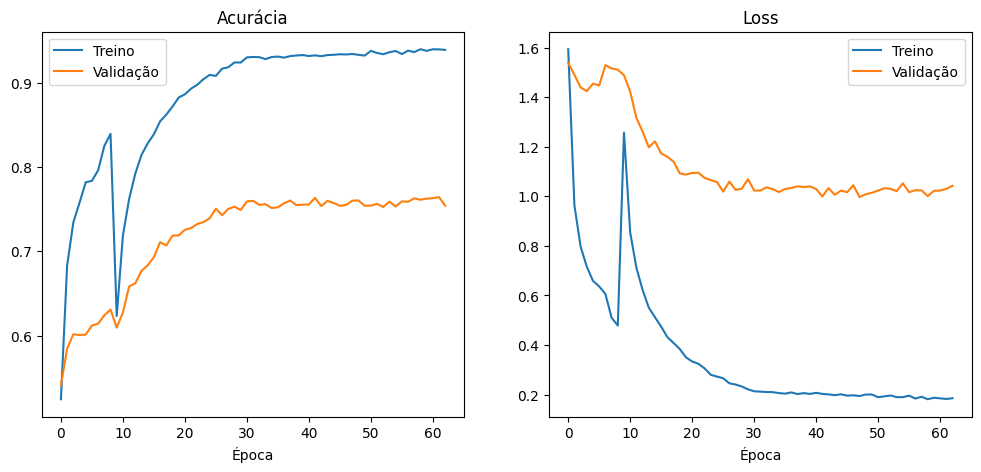

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# --- Fase 1: base pré-treinada ---
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Congelar inicialmente
for layer in base_model.layers:
    layer.trainable = False

# Cabeçalho customizado
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Treino das novas camadas
history_1 = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr]
)

# --- Fase 2: fine-tuning (descongela parcialmente) ---
for layer in base_model.layers[-30:]:  # Descongela as últimas 30 camadas
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop_ft = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

# Treino
history_2 = model.fit(
    train_generator,
    epochs=70,
    validation_data=val_generator,
    callbacks=[early_stop_ft, reduce_lr_ft]
)

# Avaliação
test_loss, test_acc = model.evaluate(X_test, to_categorical(y_test, num_classes))
print(f"\nMobileNetV2 Fine-Tuning - Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# Gráficos
plt.figure(figsize=(12,5))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history_1.history['accuracy'] + history_2.history['accuracy'], label='Treino')
plt.plot(history_1.history['val_accuracy'] + history_2.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.xlabel('Época')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_1.history['loss'] + history_2.history['loss'], label='Treino')
plt.plot(history_1.history['val_loss'] + history_2.history['val_loss'], label='Validação')
plt.title('Loss')
plt.xlabel('Época')
plt.legend()

plt.show()

Para este exercício, executou-se por duas vezes o código, obtendo resultados diferentes em cada execução.

Durante o primeiro treino, observou-se um padrão claro de overfitting: a training accuracy aumentava de forma consistente, enquanto que a validation accuracy permanecia mais baixa e irregular. Ao mesmo tempo, o val_loss mantinha valores elevados e instáveis, indicando que o modelo aprendia demasiado sobre o conjunto de treino, sem conseguir generalizar com a mesma eficácia.

Para verificar se este comportamento poderia dever-se ao estado inicial da rede ou a variações naturais entre execuções, realizou-se um segundo treino completo, mantendo exatamente os mesmos parâmetros.

Embora a segunda execução apresentasse curvas mais suaves — com uma evolução mais estável tanto no treino como na validação — o fenómeno de desfasamento entre treino e validação manteve-se visível. Isto confirma que o overfitting persistiu mesmo após repetir o treino.

No conjunto de teste, os resultados refletiram o comportamento observado durante o treino:
*   O <u>primeiro treino</u> atingiu **86.75% de accuracy** e **53.08% de loss**.
*   O <u>segundo treino</u> obteve **77.84% de accuracy** e **82.31% de loss**.

\
Embora ambos apresentem desempenho aceitável, estes valores evidenciam limitações na capacidade de generalização da MobileNetV2 nesta configuração, ficando abaixo da performance alcançada pela CNN desenvolvida no Exercício 1, que mostrou resultados mais consistentes e menos afetados por overfitting.

# **Comparação entre as duas redes**

---



<u>Para esta comparação, foram considerados os resultados do primeiro teste da rede MobileNetV2.</u>

De forma geral, os resultados finais evidenciam diferenças importantes entre as duas abordagens. A CNN desenvolvida manualmente no Exercício 1 apresentou um desempenho muito sólido, atingindo cerca de **89% de accuracy** no conjunto de teste, com curvas de treino e validação relativamente estáveis e sem sinais marcados de overfitting.

Por outro lado, o modelo do Exercício 2 — baseado na MobileNetV2 com fine-tuning — acabou por não atingir o mesmo nível de desempenho. Embora se trate de uma arquitetura avançada e pré-treinada, o seu comportamento revelou um padrão consistente de overfitting, visível no crescimento acelerado da accuracy de treino, enquanto que a validação permanecia mais irregular e acompanhada de um val_loss elevado. Mesmo após repetir o processo de treino uma segunda vez, esse desfasamento manteve-se, resultando numa accuracy de teste inferior (cerca de 86% no melhor caso). Esta diferença pode estar associada a vários fatores como, por exemplo, a necessidade de utilizar imagens com tamanho maior.

No conjunto, ambos os modelos atingem bons níveis de generalização, mas o Exercício 1 acabou por apresentar um equilíbrio mais consistente entre treino e validação, enquanto o Exercício 2 demonstrou maior instabilidade devido ao overfitting.